   # Práctica de Índices Acústicos


D. Velasco-Montero, 2026

En esta sesión de trabajo con Jupyter veremos la implementación en Scikit-maad de los **Índices acústicos** y aplicaremos los conceptos al conjunto de datos proporcionado ([Zenodo](https://zenodo.org/records/11004284)), de acuerdo a la [Guía de Usuarios de Índices Acústicos](https://ecohack.shinyapps.io/Acoustic_Index_Users_Guide/).

> Audios &rarr; Índices acústicos &rarr;  Resultados &rarr; Interpretación

Usaremos las siguientes librerías de Python:
* [Scikit-maad](https://scikit-maad.github.io/)
* [Numpy](https://numpy.org/)
* [Librosa](https://librosa.org/)
* [Matplotlib](https://matplotlib.org/)
* [Pandas](https://pandas.pydata.org/)

## 0. Instalar y cargar librerías en Python

Si no tenemos instaladas las librerías, habría que ejecutar lo siguiente:

In [ ]:
!pip install scikit-maad librosa soundfile matplotlib numpy pandas

Cargamos las librerías:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import librosa

from pathlib import Path

from maad import sound
from maad import features

## 1. Objetivos

En esta práctica aprenderemos a comparar distintos paisajes sonoros mediante índices acústicos.

Antes de calcular ningún índice intentaremos responder una pregunta: *¿Cuál de estas grabaciones contiene una mayor actividad de aves?*

In [2]:
# Lista de audios
folder = "Acoustic_index_users_guide_example_recordings/"
audios = [
    "Laughing_falcon.wav",
    "Insect_and_bird_chorus_1_Gabon.wav",    
    "Rain_in_forest_Gabon.wav",
    "Small_river.wav",
    "Road_traffic.wav",
    "Nocturnal_forest_Gabon.wav",
    "Quiet_Brazil.wav",
]

Escucha estos audios de ejemplo.

¿Qué valores (altos/bajos) esperarías de los índices acústicos más populares: ACI, ADI, NDSI, etc?

In [10]:
# Escucharlos
from IPython.display import Audio, display

'''for audio in audios:
    print(audio)
    display(Audio(folder + audio))'''
    
# Por motivos de memoria en el Notebook, recortamos los primeros segundos:
from pydub import AudioSegment
to_seg = 10 

for audio in audios:
    print(audio)
    sonido = AudioSegment.from_file(folder + audio)
    sonido_recortado = sonido[:to_seg * 1000]
    sonido_recortado.export("recortado.wav", format="wav")
    display(Audio(temp))

Laughing_falcon.wav


Insect_and_bird_chorus_1_Gabon.wav


Rain_in_forest_Gabon.wav


Small_river.wav


Road_traffic.wav


Nocturnal_forest_Gabon.wav


Quiet_Brazil.wav


## 2. Visualizar y comparar audios

### Cargar un audio

In [28]:
s, fs = librosa.load(folder + audios[0], sr=None)

print(fs)
print(s.shape)

32000
(1920000,)


### Visualizar la señal

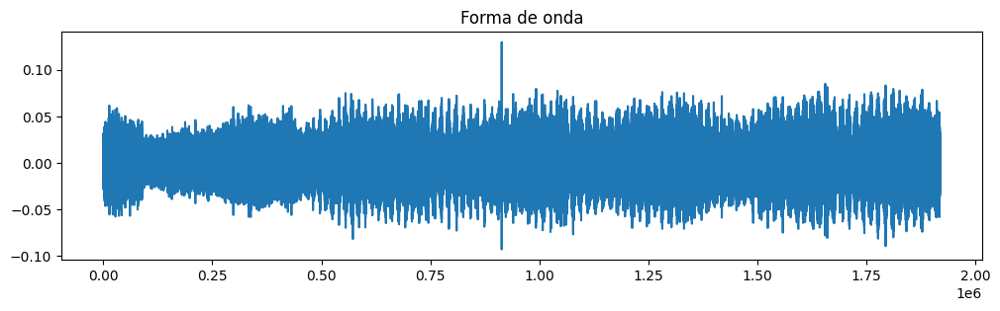

In [30]:
plt.figure(figsize=(12,3))
plt.plot(s)
plt.title("Forma de onda")
plt.show()

### Visualizar el espectrograma

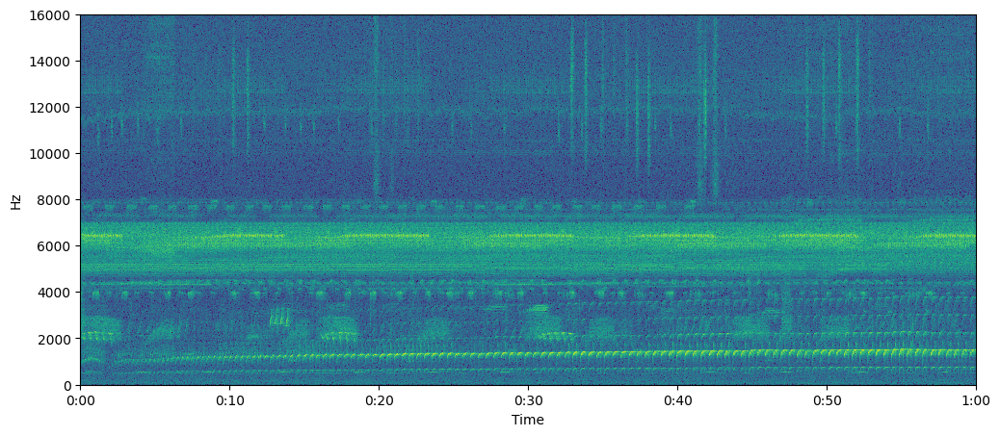

In [31]:
import librosa.display

D = librosa.amplitude_to_db(
    abs(librosa.stft(s)),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=fs,
    x_axis="time",
    y_axis="hz",
    cmap="viridis"
)

### Comparar las 5 grabaciones de estudio

In [33]:
# Función para isualizar un audio y su espectrograma
def mostrar_audio(audio):

    # Cargar audio
    s, fs = sound.load(audio, detrend=False)

    # Espectrograma en dB
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(s)),
        ref=np.max
    )

    # Crear figura con 2 subplots
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

    # -------------------------
    # Forma de onda
    # -------------------------
    tiempo = np.arange(len(s)) / fs

    ax[0].plot(tiempo, s, color="steelblue")
    ax[0].set_title(f"{audio}")
    ax[0].set_ylabel("Amplitud")
    ax[0].set_xlabel("Tiempo (s)")
    ax[0].grid(alpha=0.3)

    # -------------------------
    # Espectrograma
    # -------------------------
    img = librosa.display.specshow(
        D,
        sr=fs,
        x_axis="time",
        y_axis="hz",
        cmap="viridis",
        ax=ax[1]
    )

    ax[1].set_title("Espectrograma")
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")

    plt.show()

    return s, fs, D

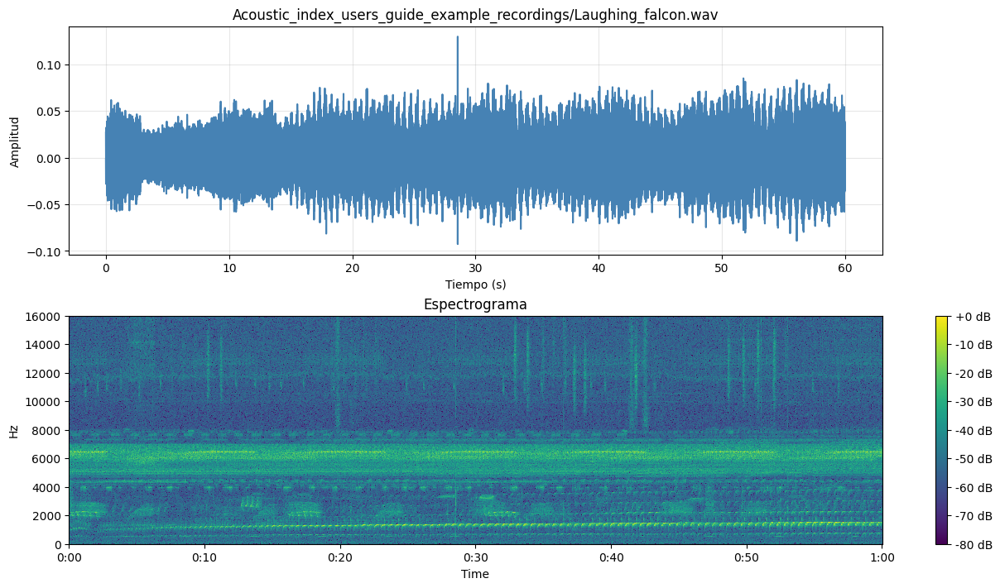

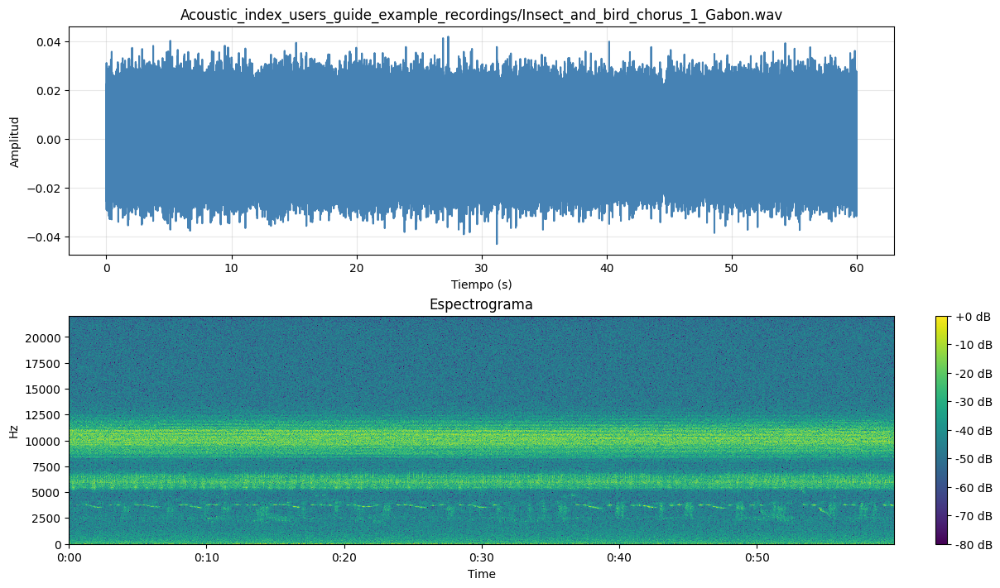

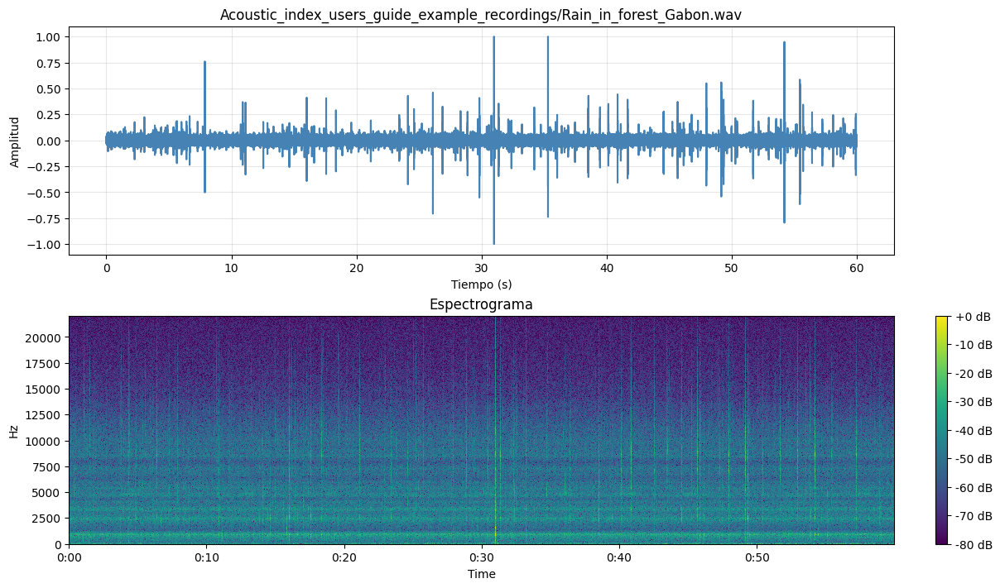

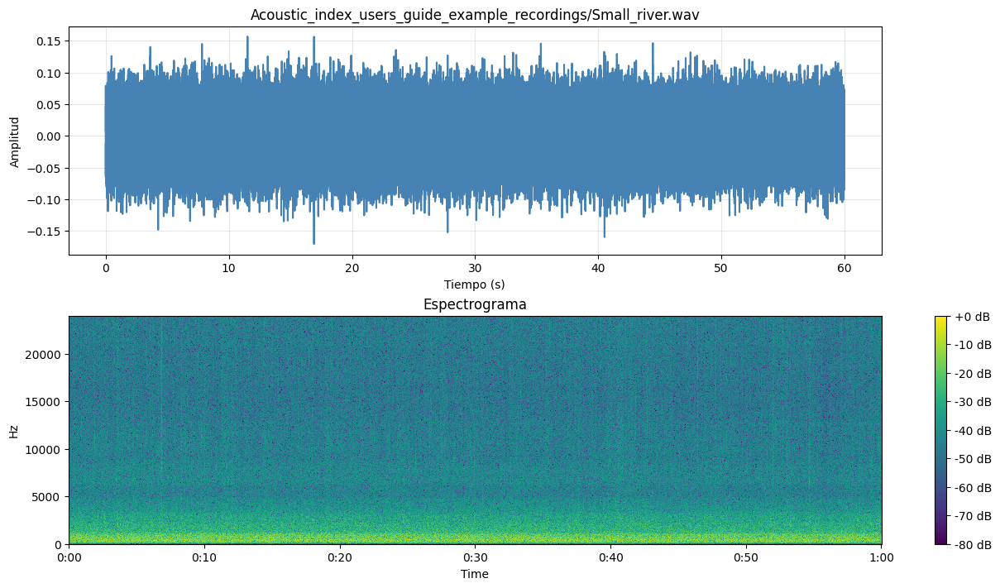

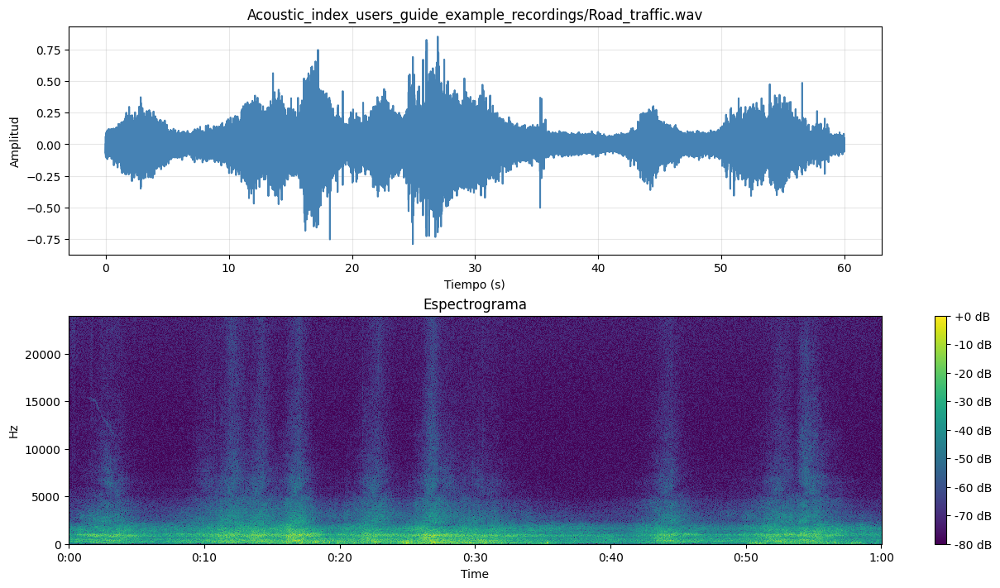

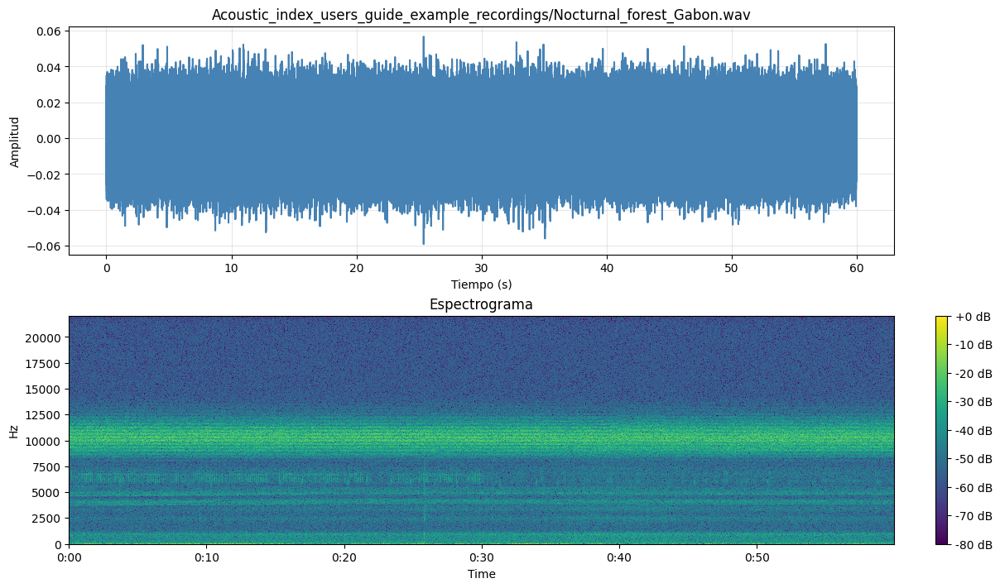

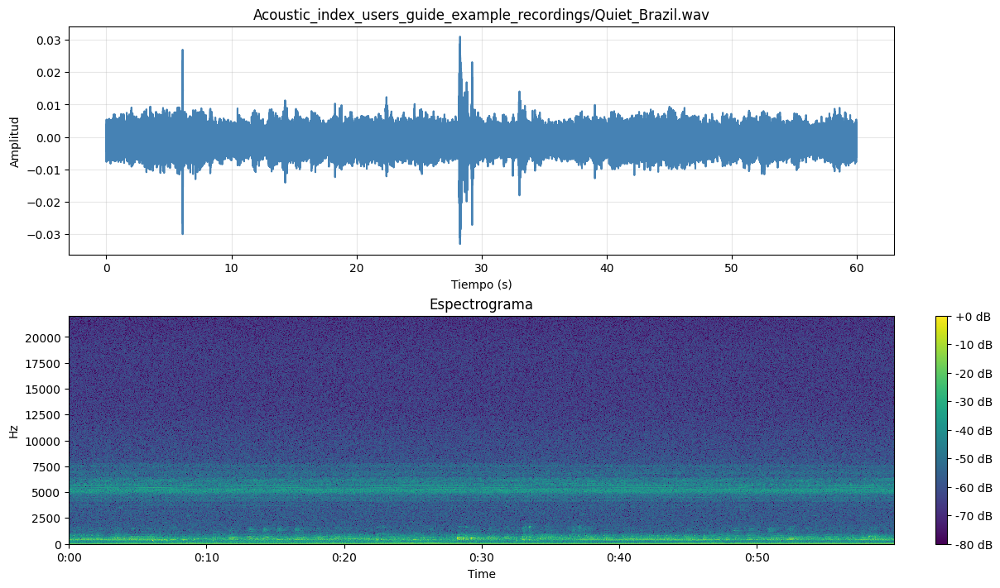

In [34]:
for audio in audios:
    s, fs, D = mostrar_audio(folder + audio)

## 3. Cálculo de Índices Acústicos

In [35]:
# Función para calcular índices usando maad.features
def calcular_indices(audio):

    s, fs = sound.load(audio, detrend=False)

    Sxx, tn, fn, ext = sound.spectrogram(
        s,
        fs,
        detrend=False
    )

    df_indices, df_bins = features.all_spectral_alpha_indices(
        Sxx,
        tn,
        fn
    )

    df_indices["Audio"] = Path(audio).stem

    return df_indices

In [36]:
# Procesar todos los audios para calcular los índices acústicos
lista = []
for audio in audios:
    lista.append(calcular_indices(folder + audio))

resultados = pd.concat(lista)
resultados = resultados.set_index("Audio")

¿Qué resultados nos devuelve?

In [37]:
resultados.columns

Index(['MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf', 'ENRf', 'BGNf',
       'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT', 'EPS_SKEW', 'ACI',
       'NDSI', 'rBA', 'AnthroEnergy', 'BioEnergy', 'BI', 'ROU', 'ADI', 'AEI',
       'LFC', 'MFC', 'HFC', 'ACTspFract', 'ACTspCount', 'ACTspMean',
       'EVNspFract', 'EVNspMean', 'EVNspCount', 'TFSD', 'H_Havrda', 'H_Renyi',
       'H_pairedShannon', 'H_gamma', 'H_GiniSimpson', 'RAOQ', 'AGI',
       'ROItotal', 'ROIcover'],
      dtype='object')

De estos índices, ¿cuáles podemos comparar a modo ilustrativo?

In [38]:
# Seleccionar únicamente los más interesantes
indices = resultados[
    [
        "ACI", # acoustic complexity index: complejidad acústica
        "ADI", # acoustic diversity index: diversidad acústica
        "AEI", # acoustic evenness index: uniformidad acústica
        "BI",  # bioacoustic index: intensidad biológica
        "NDSI", # normalized diference soundscape index: antropofonía vs biofonía
    ]
]
indices

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Laughing_falcon,296.853917,2.186589,0.235127,113.938897,0.355791
Insect_and_bird_chorus_1_Gabon,297.078505,2.301191,0.029177,43.206818,0.901479
Rain_in_forest_Gabon,338.755894,2.241586,0.198113,30.416201,0.057581
Small_river,301.580349,2.300329,0.037862,23.804401,-0.674362
Road_traffic,297.487091,1.398651,0.680675,47.172050,-0.777914
Nocturnal_forest_Gabon,297.460393,2.287309,0.098003,38.937043,0.673915
Quiet_Brazil,292.668046,1.784321,0.534475,37.559345,-0.823979


Como cada índice tiene una escala distinta, también podemos normalizarlos antes de compararlos:

In [39]:
# Normalizar para comparar perfiles
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
norm = pd.DataFrame(
    scaler.fit_transform(indices),
    columns=indices.columns,
    index=indices.index
)

Los podemos mostrar con un mapa de color:

In [40]:
norm.style.background_gradient(cmap="viridis")

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Laughing_falcon,0.090824,0.873023,0.316118,1.000000,0.683743
Insect_and_bird_chorus_1_Gabon,0.095697,1.000000,0.000000,0.215261,1.000000
Rain_in_forest_Gabon,1.000000,0.933958,0.259304,0.073355,0.510914
Small_river,0.193376,0.999045,0.013332,0.000000,0.086712
Road_traffic,0.104562,0.000000,1.000000,0.259253,0.026697
Nocturnal_forest_Gabon,0.103983,0.984619,0.105643,0.167890,0.868114
Quiet_Brazil,0.000000,0.427317,0.775593,0.152605,0.000000


### Análisis por índices

#### ACI: complejidad acústica.
- Valores altos: gran complejidad acústica (actividad biológica irregular o eventos como tormentas). 
- Valores bajos: ruido constante.

In [41]:
# Ranking por ACI
indices.sort_values("ACI", ascending=False)

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Rain_in_forest_Gabon,338.755894,2.241586,0.198113,30.416201,0.057581
Small_river,301.580349,2.300329,0.037862,23.804401,-0.674362
Road_traffic,297.487091,1.398651,0.680675,47.172050,-0.777914
Nocturnal_forest_Gabon,297.460393,2.287309,0.098003,38.937043,0.673915
Insect_and_bird_chorus_1_Gabon,297.078505,2.301191,0.029177,43.206818,0.901479
Laughing_falcon,296.853917,2.186589,0.235127,113.938897,0.355791
Quiet_Brazil,292.668046,1.784321,0.534475,37.559345,-0.823979


La lluvia produce el valor más alto; el río también tiene un ACI relativamente elevado.

*El ACI mide complejidad acústica, no biodiversidad.*

#### Acoustic Diversity Index (ADI) e Acoustic Evenness index (AEI) - complementarios

- Valores altos de ADI y bajos de AEI: el sonido está distribuido de forma diversa entre las bandas de frecuencia.


In [42]:
# Ranking por ADI
indices.sort_values("ADI", ascending=False)
#indices.sort_values("AEI", ascending=True)

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Insect_and_bird_chorus_1_Gabon,297.078505,2.301191,0.029177,43.206818,0.901479
Small_river,301.580349,2.300329,0.037862,23.804401,-0.674362
Nocturnal_forest_Gabon,297.460393,2.287309,0.098003,38.937043,0.673915
Rain_in_forest_Gabon,338.755894,2.241586,0.198113,30.416201,0.057581
Laughing_falcon,296.853917,2.186589,0.235127,113.938897,0.355791
Quiet_Brazil,292.668046,1.784321,0.534475,37.559345,-0.823979
Road_traffic,297.487091,1.398651,0.680675,47.172050,-0.777914


El coro de aves reparte energía en muchas bandas → ADI alto y AEI muy bajo.

El tráfico concentra la energía en pocas bandas → ADI bajo y AEI alto.

#### Bioacoustic index

- Valores altos: mayor abundancia o intensidad de señales en el rango de frecuencia biológico (2-8 kHz por defecto)


In [43]:
# Ranking por BIO
indices.sort_values("BI", ascending=False)

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Laughing_falcon,296.853917,2.186589,0.235127,113.938897,0.355791
Road_traffic,297.487091,1.398651,0.680675,47.172050,-0.777914
Insect_and_bird_chorus_1_Gabon,297.078505,2.301191,0.029177,43.206818,0.901479
Nocturnal_forest_Gabon,297.460393,2.287309,0.098003,38.937043,0.673915
Quiet_Brazil,292.668046,1.784321,0.534475,37.559345,-0.823979
Rain_in_forest_Gabon,338.755894,2.241586,0.198113,30.416201,0.057581
Small_river,301.580349,2.300329,0.037862,23.804401,-0.674362


El valor del *Laughing Falcon* es totalmente esperable: una vocalización potente y dominante genera un Bioacoustic index muy alto.

Notar que el tráfico también tiene un valor alto. Este índice suma energía en una banda de frecuencias definida, y un vehículo puede aportar mucha energía en parte de ese rango. Por eso el BI tampoco debe interpretarse como "más aves = BI más alto".

#### NDSI (normalized diference soundscape index)

- Valores cercanos a 1: paisaje sonoro dominado por biofonía. 
- Valores negativos cercanos a -1: dominado por antropofonía.

In [44]:
# Ranking por NDSI
indices.sort_values("NDSI", ascending=False)

,ACI,ADI,AEI,BI,NDSI
Audio,,,,,
Insect_and_bird_chorus_1_Gabon,297.078505,2.301191,0.029177,43.206818,0.901479
Nocturnal_forest_Gabon,297.460393,2.287309,0.098003,38.937043,0.673915
Laughing_falcon,296.853917,2.186589,0.235127,113.938897,0.355791
Rain_in_forest_Gabon,338.755894,2.241586,0.198113,30.416201,0.057581
Small_river,301.580349,2.300329,0.037862,23.804401,-0.674362
Road_traffic,297.487091,1.398651,0.680675,47.172050,-0.777914
Quiet_Brazil,292.668046,1.784321,0.534475,37.559345,-0.823979


Coro de aves → muy biofónico.

Bosque nocturno → predominantemente biológico.

Lluvia → equilibrio entre biofonía y ruido.

Río y tráfico → dominados por energía de baja frecuencia, indicador antropofónico.

## 4. Discusión


Pregunta 1. ¿Qué grabación parece contener mayor actividad de aves? ¿Coincide con el mayor ACI?

Pregunta 2. ¿Qué índice discrimina mejor entre tráfico y bosque?

Pregunta 3. ¿Qué limitaciones presenta el ACI?

Pregunta 4. ¿Utilizarías un único índice para monitorizar aves?